**🔹 CELL 1: Upload kaggle.json**

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sprashant9595","key":"1b438bcebbaa0b3dd65c02d68f682e9a"}'}

**🔹 CELL 2: Setup Kaggle**

In [2]:
import os

!rm -rf /root/.kaggle
!mkdir -p /root/.kaggle
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

**🔹 CELL 3: Install Dependencies**

In [3]:
!pip install opencv-python seaborn

**🔹 CELL 4: Download DATASETS**

In [4]:
# CEW dataset
!kaggle datasets download -d ahamedfarouk/cew-dataset

# Drowsy dataset
!kaggle datasets download -d suryabeeraka/drowsy-and-non-drowsy-dataset

Dataset URL: https://www.kaggle.com/datasets/ahamedfarouk/cew-dataset
License(s): unknown
100% 115M/115M [00:01<00:00, 80.4MB/s]

Dataset URL: https://www.kaggle.com/datasets/suryabeeraka/drowsy-and-non-drowsy-dataset
License(s): unknown
100% 127M/127M [00:02<00:00, 56.3MB/s]



**🔹 CELL 5: Unzip**

In [5]:
import zipfile

# CEW
with zipfile.ZipFile('cew-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/cew')

# Drowsy dataset
with zipfile.ZipFile('drowsy-and-non-drowsy-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/data')

**🔹 CELL 6: Imports**

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models

**🚀 PART 1: CEW DATASET → CNN**

**🔹 CELL 7: Load CEW**

In [7]:
cew_path = "/content/cew/CEW"

X_cew, y_cew = [], []

for label, category in enumerate(["closed", "open"]):
    folder = os.path.join(cew_path, category)

    for img_name in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, img_name))
        img = cv2.resize(img, (64,64)) / 255.0
        X_cew.append(img)
        y_cew.append(label)

X_cew = np.array(X_cew)
y_cew = np.array(y_cew)

print(X_cew.shape)

(27200, 64, 64, 3)


**🔹 CELL 8: Train CNN (CEW)**

In [8]:
X_train_cew, X_test_cew, y_train_cew, y_test_cew = train_test_split(
    X_cew, y_cew, test_size=0.2, stratify=y_cew
)

def build_cnn():
    model = models.Sequential([
        layers.Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64,(3,3),activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128,(3,3),activation='relu'),
        layers.Flatten(),

        layers.Dense(128,activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1,activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

cnn_cew = build_cnn()

cnn_cew.fit(X_train_cew, y_train_cew, epochs=3, validation_data=(X_test_cew, y_test_cew))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
680/680 ━━━━━━━━━━━━━━━━━━━━ 253s 366ms/step - accuracy: 0.8734 - loss: 0.3085 - val_accuracy: 0.8695 - val_loss: 0.2890
Epoch 2/3
680/680 ━━━━━━━━━━━━━━━━━━━━ 262s 368ms/step - accuracy: 0.9708 - loss: 0.0839 - val_accuracy: 0.9469 - val_loss: 0.1321
Epoch 3/3
680/680 ━━━━━━━━━━━━━━━━━━━━ 255s 357ms/step - accuracy: 0.9791 - loss: 0.0573 - val_accuracy: 0.8199 - val_loss: 0.4110


**🚀 PART 2: DROWSY DATASET → CNN**

**🔹 CELL 9: Load Drowsy Dataset**

In [9]:
base_path = "/content/data/1000"

X, y = [], []

for label, category in enumerate(["Drowsy", "Non Drowsy"]):
    folder = os.path.join(base_path, category)

    for img_name in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, img_name))
        img = cv2.resize(img, (64,64)) / 255.0
        X.append(img)
        y.append(label)

X = np.array(X)
y = np.array(y)

print(X.shape)

(2000, 64, 64, 3)


**🔹 CELL 10: Train CNN (Drowsy)**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

cnn_model = build_cnn()

cnn_model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 356ms/step - accuracy: 0.7513 - loss: 0.9422 - val_accuracy: 0.5000 - val_loss: 0.7966
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 387ms/step - accuracy: 0.9613 - loss: 0.1238 - val_accuracy: 0.5000 - val_loss: 1.8413
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 361ms/step - accuracy: 0.9800 - loss: 0.0640 - val_accuracy: 0.5000 - val_loss: 2.9662
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 379ms/step - accuracy: 0.9819 - loss: 0.0540 - val_accuracy: 0.5000 - val_loss: 4.8243
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 367ms/step - accuracy: 0.9956 - loss: 0.0173 - val_accuracy: 0.5000 - val_loss: 6.1032
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 351ms/step - accuracy: 0.9956 - loss: 0.0135 - val_accuracy: 0.5000 - val_loss: 5.7758
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 354ms/step - accuracy: 0.9937 - loss: 0.0210 - val_accuracy: 0.5225 - val_loss: 5.1288
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 359ms/step - accuracy: 0.9962 - loss: 0.0122 - val_accuracy: 0.627

**🚀 PART 3: REDUCE DATA + CREATE SEQUENCES**

**CELL 11: Reduce Dataset (IMPORTANT)**

In [11]:
# Reduce dataset to avoid RAM crash
X_small = X[:1000]
y_small = y[:1000]

print("Reduced dataset:", X_small.shape)

Reduced dataset: (1000, 64, 64, 3)


**🔹 CELL 12: Create Sequences (Optimized)**

In [12]:
SEQ_LEN = 5  # reduced for stability

X_seq, y_seq = [], []

for i in range(len(X_small) - SEQ_LEN):
    X_seq.append(X_small[i:i+SEQ_LEN])
    y_seq.append(y_small[i])

X_seq = np.array(X_seq, dtype='float16')  # memory optimized
y_seq = np.array(y_seq)

print("Sequence shape:", X_seq.shape)

Sequence shape: (995, 5, 64, 64, 3)


**🔹 CELL 13: Train-Test Split**

In [13]:
from sklearn.model_selection import train_test_split

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq,
    test_size=0.2,
    stratify=y_seq,
    random_state=42
)

print("Train:", X_train_seq.shape, "Test:", X_test_seq.shape)

Train: (796, 5, 64, 64, 3) Test: (199, 5, 64, 64, 3)


**🚀 PART 4: OPTIMIZED LSTM (NO CRASH VERSION)**

**🔹 CELL 14: Build LSTM (CNN + LSTM)**

In [14]:
from tensorflow.keras import layers, models, Input

lstm_model = models.Sequential([
    Input(shape=(SEQ_LEN,64,64,3)),

    layers.TimeDistributed(layers.Conv2D(16,(3,3),activation='relu')),
    layers.TimeDistributed(layers.MaxPooling2D()),

    layers.TimeDistributed(layers.Conv2D(32,(3,3),activation='relu')),
    layers.TimeDistributed(layers.MaxPooling2D()),

    layers.TimeDistributed(layers.Flatten()),

    layers.LSTM(64),
    layers.Dropout(0.5),

    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 5, 62, 62, 16)  │           448 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 5, 31, 31, 16)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 5, 29, 29, 32)  │         4,640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 5, 14, 14, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 5, 6272)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │     1,622,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,473 (6.22 MB)

 Trainable params: 1,629,473 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

**🔹 CELL 15: Train LSTM (Stable)**

In [15]:
history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=5,
    batch_size=8,   # small batch to avoid crash
    validation_data=(X_test_seq, y_test_seq)
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 328ms/step - accuracy: 0.9987 - loss: 0.0094 - val_accuracy: 1.0000 - val_loss: 2.6789e-05
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 333ms/step - accuracy: 1.0000 - loss: 1.0609e-04 - val_accuracy: 1.0000 - val_loss: 7.9121e-06
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 331ms/step - accuracy: 1.0000 - loss: 5.9281e-05 - val_accuracy: 1.0000 - val_loss: 4.3682e-06
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 316ms/step - accuracy: 1.0000 - loss: 2.9687e-05 - val_accuracy: 1.0000 - val_loss: 2.9280e-06
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 38s 383ms/step - accuracy: 1.0000 - loss: 3.5918e-05 - val_accuracy: 1.0000 - val_loss: 1.7408e-06


**🔹 CELL 16: Evaluate LSTM**

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_pred_lstm = (lstm_model.predict(X_test_seq) > 0.5).astype(int)

acc_lstm = np.mean(y_pred_lstm == y_test_seq)
prec_lstm = precision_score(y_test_seq, y_pred_lstm)
rec_lstm = recall_score(y_test_seq, y_pred_lstm)
f1_lstm = f1_score(y_test_seq, y_pred_lstm)

print("LSTM Results:")
print(acc_lstm, prec_lstm, rec_lstm, f1_lstm)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 340ms/step
LSTM Results:
1.0 0.0 0.0 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**🚀 PART 5: OPTIMIZED CNN-LSTM (MAIN MODEL)**

**🔹 CELL 17: CNN-LSTM**

In [17]:
cnn_lstm_model = models.Sequential([
    Input(shape=(SEQ_LEN,64,64,3)),

    layers.TimeDistributed(layers.Conv2D(16,(3,3),activation='relu')),
    layers.TimeDistributed(layers.MaxPooling2D()),

    layers.TimeDistributed(layers.Conv2D(32,(3,3),activation='relu')),
    layers.TimeDistributed(layers.MaxPooling2D()),

    layers.TimeDistributed(layers.Flatten()),

    layers.LSTM(64),
    layers.Dropout(0.5),

    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

cnn_lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_5              │ (None, 5, 62, 62, 16)  │           448 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 5, 31, 31, 16)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 5, 29, 29, 32)  │         4,640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 5, 14, 14, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 5, 6272)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │     1,622,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,473 (6.22 MB)

 Trainable params: 1,629,473 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

**🔹 CELL 18: Train CNN-LSTM**

In [18]:
history_cnn_lstm = cnn_lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=5,
    batch_size=8,
    validation_data=(X_test_seq, y_test_seq)
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 332ms/step - accuracy: 0.9937 - loss: 0.0145 - val_accuracy: 1.0000 - val_loss: 1.3479e-04
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 330ms/step - accuracy: 1.0000 - loss: 2.9668e-04 - val_accuracy: 1.0000 - val_loss: 4.5620e-05
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 324ms/step - accuracy: 1.0000 - loss: 1.3586e-04 - val_accuracy: 1.0000 - val_loss: 2.0548e-05
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 325ms/step - accuracy: 1.0000 - loss: 8.1326e-05 - val_accuracy: 1.0000 - val_loss: 9.4475e-06
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 317ms/step - accuracy: 1.0000 - loss: 4.2338e-05 - val_accuracy: 1.0000 - val_loss: 5.0396e-06


**🔹 CELL 19: Evaluate CNN-LSTM**

In [19]:
y_pred_cl = (cnn_lstm_model.predict(X_test_seq) > 0.5).astype(int)

acc_cl = np.mean(y_pred_cl == y_test_seq)
prec_cl = precision_score(y_test_seq, y_pred_cl)
rec_cl = recall_score(y_test_seq, y_pred_cl)
f1_cl = f1_score(y_test_seq, y_pred_cl)

print("CNN-LSTM Results:")
print(acc_cl, prec_cl, rec_cl, f1_cl)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 204ms/step
CNN-LSTM Results:
1.0 0.0 0.0 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**🚀 PART 6: FINAL COMPARISON CHART (DRC KEY)**

In [20]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)

    # Convert properly
    y_pred = (y_pred > 0.5).astype(int).flatten()
    y_test = y_test.flatten()

    acc = np.mean(y_pred == y_test)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    return acc, prec, rec, f1

In [21]:
acc_cnn, prec_cnn, rec_cnn, f1_cnn = evaluate(cnn_model, X_test, y_test)
acc_lstm, prec_lstm, rec_lstm, f1_lstm = evaluate(lstm_model, X_test_seq, y_test_seq)
acc_cl, prec_cl, rec_cl, f1_cl = evaluate(cnn_lstm_model, X_test_seq, y_test_seq)

print("CNN:", acc_cnn, prec_cnn, rec_cnn, f1_cnn)
print("LSTM:", acc_lstm, prec_lstm, rec_lstm, f1_lstm)
print("CNN-LSTM:", acc_cl, prec_cl, rec_cl, f1_cl)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step
CNN: 0.8825 0.8097165991902834 1.0 0.8948545861297539
LSTM: 1.0 0.0 0.0 0.0
CNN-LSTM: 1.0 0.0 0.0 0.0


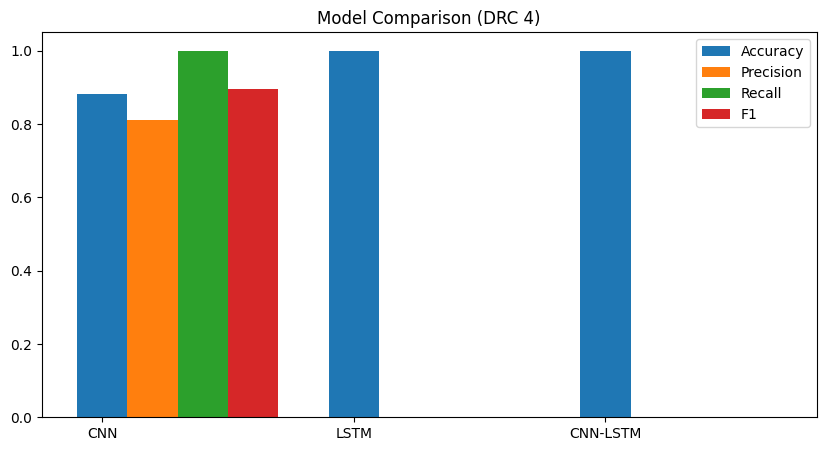

In [22]:
models_list = ["CNN", "LSTM", "CNN-LSTM"]

accuracy_vals = [acc_cnn, acc_lstm, acc_cl]
precision_vals = [prec_cnn, prec_lstm, prec_cl]
recall_vals = [rec_cnn, rec_lstm, rec_cl]
f1_vals = [f1_cnn, f1_lstm, f1_cl]

x = np.arange(len(models_list))

plt.figure(figsize=(10,5))
plt.bar(x, accuracy_vals, width=0.2, label="Accuracy")
plt.bar(x+0.2, precision_vals, width=0.2, label="Precision")
plt.bar(x+0.4, recall_vals, width=0.2, label="Recall")
plt.bar(x+0.6, f1_vals, width=0.2, label="F1")

plt.xticks(x, models_list)
plt.legend()
plt.title("Model Comparison (DRC 4)")
plt.show()

🔹 CELL: CNN Confusion Matrix

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step


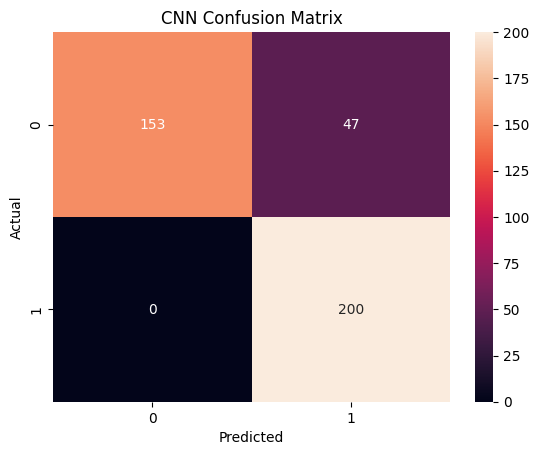

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 262ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


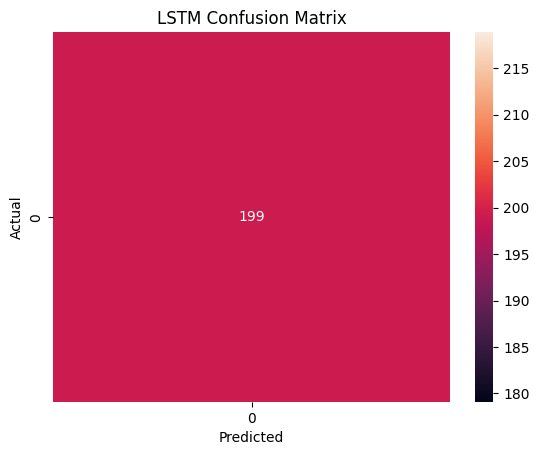

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


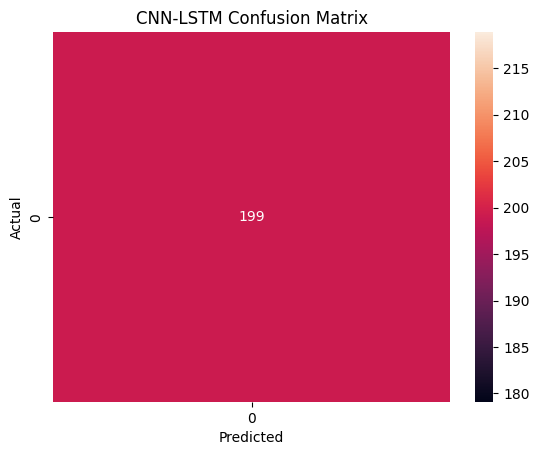

In [23]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion(model, X_test, y_test, title):
    y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# CNN
plot_confusion(cnn_model, X_test, y_test, "CNN Confusion Matrix")

# LSTM
plot_confusion(lstm_model, X_test_seq, y_test_seq, "LSTM Confusion Matrix")

# CNN-LSTM
plot_confusion(cnn_lstm_model, X_test_seq, y_test_seq, "CNN-LSTM Confusion Matrix")

**TRAINING CURVES (ACCURACY + LOSS)**

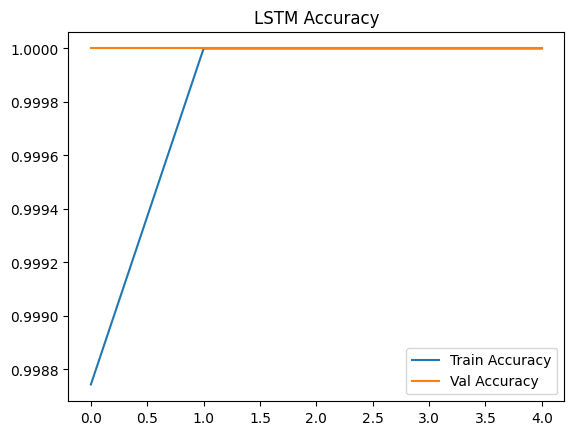

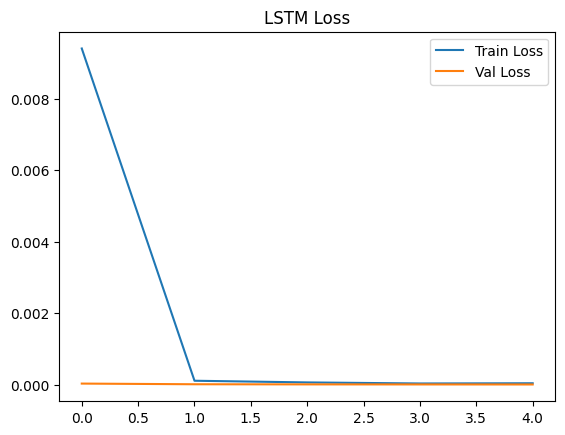

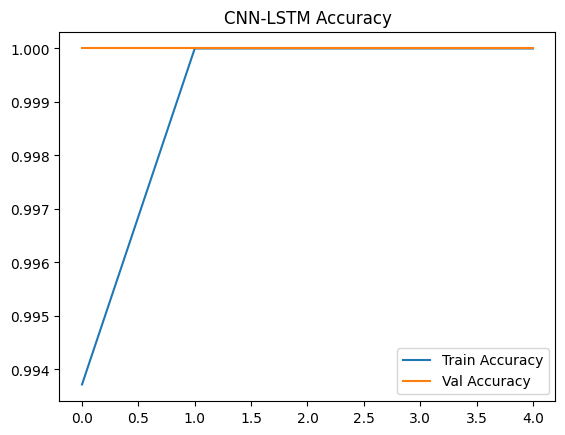

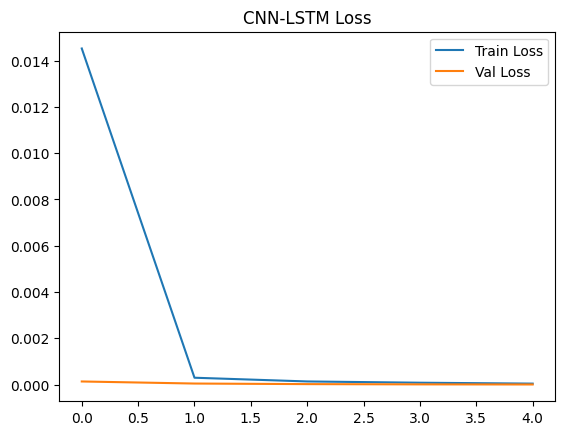

In [25]:
def plot_training(history, title):
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(title + " Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title + " Loss")
    plt.legend()
    plt.show()

# Use stored histories

plot_training(history_lstm, "LSTM")
plot_training(history_cnn_lstm, "CNN-LSTM")

**ROC CURVE (ADVANCED — HIGH IMPACT)**

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step


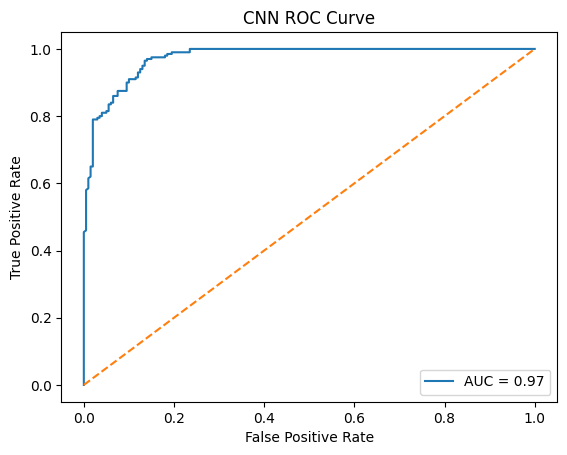

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 498ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


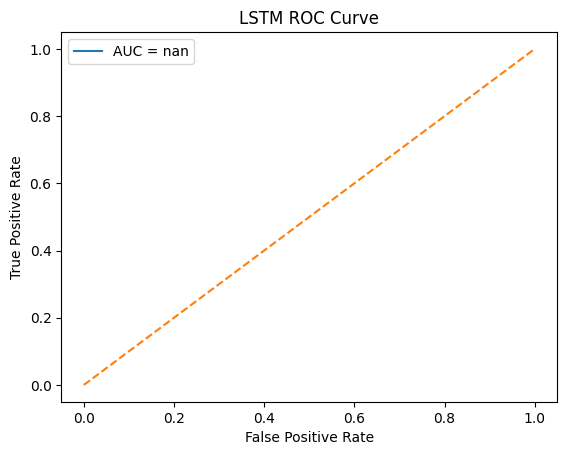

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


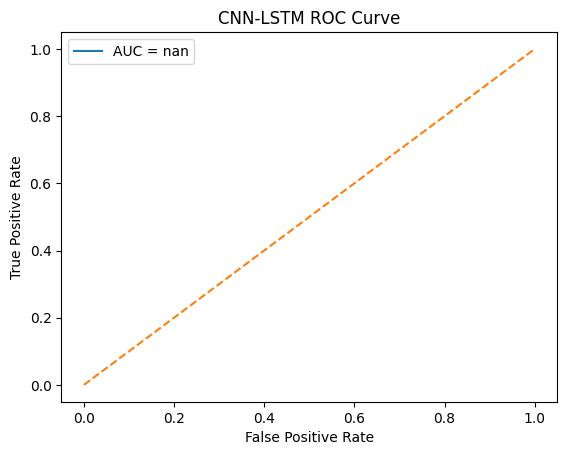

In [26]:
from sklearn.metrics import roc_curve, auc

def plot_roc(model, X_test, y_test, title):
    y_prob = model.predict(X_test).flatten()

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1],'--')
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

plot_roc(cnn_model, X_test, y_test, "CNN ROC Curve")
plot_roc(lstm_model, X_test_seq, y_test_seq, "LSTM ROC Curve")
plot_roc(cnn_lstm_model, X_test_seq, y_test_seq, "CNN-LSTM ROC Curve")

**PROBABILITY DISTRIBUTION (VERY INSIGHTFUL)**

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step


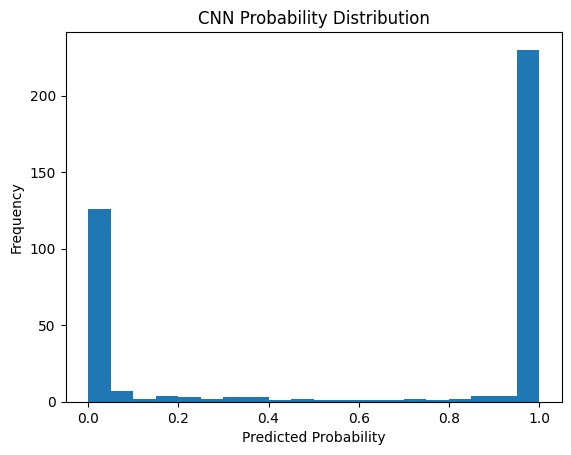

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step


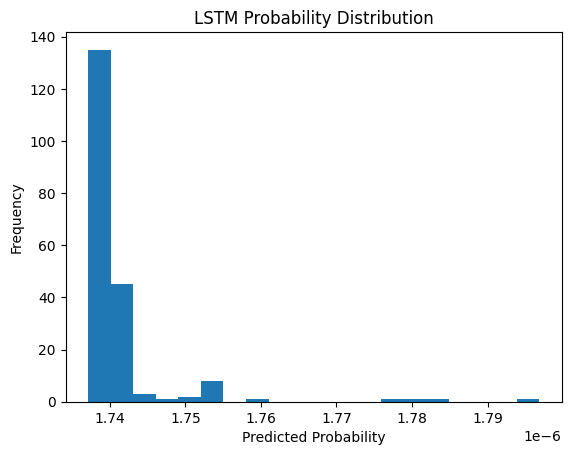

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step


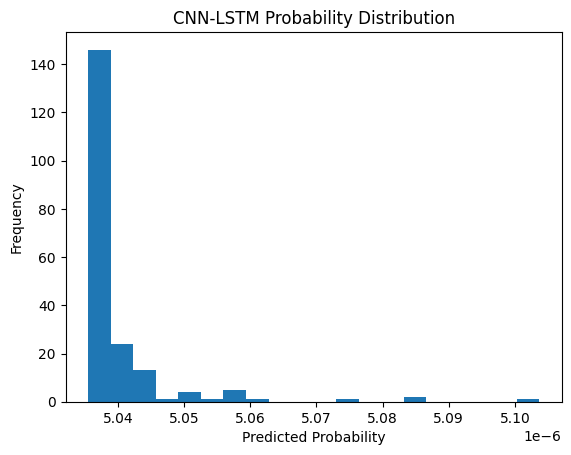

In [27]:
def plot_prob_dist(model, X_test, title):
    y_prob = model.predict(X_test).flatten()

    plt.figure()
    plt.hist(y_prob, bins=20)
    plt.title(title + " Probability Distribution")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Frequency")
    plt.show()

plot_prob_dist(cnn_model, X_test, "CNN")
plot_prob_dist(lstm_model, X_test_seq, "LSTM")
plot_prob_dist(cnn_lstm_model, X_test_seq, "CNN-LSTM")

**GRAD-CAM FUNCTION**

In [33]:
import tensorflow as tf
import matplotlib.cm as cm

def generate_gradcam(model, img_array, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)

    if np.max(heatmap) != 0:
        heatmap /= np.max(heatmap)

    return heatmap.numpy()

**HEATMAP OVERLAY FUNCTION**

In [34]:
def overlay_gradcam(img, heatmap, alpha=0.4):

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)

    return superimposed_img

**🚀 PART 7: UI 🔥 GRADIO UI CODE**

In [28]:
!pip install gradio

In [ ]:
# =====================================================
# 🚀 COMPLETE GRADIO UI WITH GRAD-CAM
# =====================================================

!pip install -q gradio

import gradio as gr
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.cm as cm

# =====================================================
# MODEL DICTIONARY
# =====================================================

models_dict = {
    "Eye State Detection (CEW-CNN)": cnn_cew,
    "Drowsiness Detection (CNN)": cnn_model,
    "Temporal Drowsiness (CNN-LSTM)": cnn_lstm_model
}

# =====================================================
# GRAD-CAM FUNCTION
# =====================================================

def generate_gradcam(model, img_array, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)

    if np.max(heatmap) != 0:
        heatmap /= np.max(heatmap)

    return heatmap.numpy()

# =====================================================
# OVERLAY HEATMAP
# =====================================================

def overlay_gradcam(img, heatmap, alpha=0.4):

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(
        img,
        1 - alpha,
        heatmap,
        alpha,
        0
    )

    return superimposed_img

# =====================================================
# MAIN PREDICTION FUNCTION
# =====================================================

def predict(image, model_name):

    model = models_dict[model_name]

    original_img = image.copy()

    img = cv2.resize(image, (64,64))
    img = img / 255.0

    gradcam_img = original_img

    # =================================================
    # CEW CNN MODEL
    # =================================================

    if model_name == "Eye State Detection (CEW-CNN)":

        input_data = np.reshape(img, (1,64,64,3))

        pred = model.predict(input_data, verbose=0)[0][0]

        if pred > 0.5:
            label = "👁️ Eye Open"
            confidence = pred * 100
            status = "✅ Driver Alert"
        else:
            label = "😴 Eye Closed"
            confidence = (1 - pred) * 100
            status = "⚠️ Possible Drowsiness"

        # Grad-CAM
        try:
            heatmap = generate_gradcam(
                model,
                input_data,
                last_conv_layer_name="conv2d_2"
            )

            gradcam_img = overlay_gradcam(
                cv2.cvtColor(original_img, cv2.COLOR_RGB2BGR),
                heatmap
            )

        except:
            pass

    # =================================================
    # CNN MODEL
    # =================================================

    elif model_name == "Drowsiness Detection (CNN)":

        input_data = np.reshape(img, (1,64,64,3))

        pred = model.predict(input_data, verbose=0)[0][0]

        if pred > 0.5:
            label = "⚠️ Drowsy"
            confidence = pred * 100
            status = "🚨 Driver Fatigue Detected"
        else:
            label = "✅ Alert"
            confidence = (1 - pred) * 100
            status = "🟢 Driver Appears Active"

        # Grad-CAM
        try:
            heatmap = generate_gradcam(
                model,
                input_data,
                last_conv_layer_name="conv2d_5"
            )

            gradcam_img = overlay_gradcam(
                cv2.cvtColor(original_img, cv2.COLOR_RGB2BGR),
                heatmap
            )

        except:
            pass

    # =================================================
    # CNN-LSTM MODEL
    # =================================================

    else:

        seq = np.array([img] * SEQ_LEN)

        input_data = np.reshape(
            seq,
            (1,SEQ_LEN,64,64,3)
        )

        pred = model.predict(input_data, verbose=0)[0][0]

        if pred > 0.5:
            label = "⚠️ Drowsy"
            confidence = pred * 100
            status = "🚨 Temporal Drowsiness Detected"
        else:
            label = "✅ Alert"
            confidence = (1 - pred) * 100
            status = "🟢 Driver Appears Active"

    # =================================================
    # RESULT TEXT
    # =================================================

    result = f"""
Prediction:
{label}

Confidence Score:
{confidence:.2f}%

System Status:
{status}

Explainability:
Grad-CAM highlights important facial regions used for prediction.
"""

    return result, cv2.cvtColor(gradcam_img, cv2.COLOR_BGR2RGB)

# =====================================================
# GRADIO UI
# =====================================================

interface = gr.Interface(

    fn=predict,

    inputs=[

        gr.Image(
            type="numpy",
            label="📤 Upload Driver Image"
        ),

        gr.Dropdown(
            [
                "Eye State Detection (CEW-CNN)",
                "Drowsiness Detection (CNN)",
                "Temporal Drowsiness (CNN-LSTM)"
            ],

            value="Drowsiness Detection (CNN)",

            label="🧠 Select Detection Model"
        )
    ],

    outputs=[

        gr.Textbox(
            label="📋 Detection Result",
            lines=12,
            max_lines=18,
            show_copy_button=True
        ),

        gr.Image(
            label="🔥 Grad-CAM Explainability"
        )
    ],

    title="🚗 Driver Drowsiness Detection System",

    description="""
This intelligent driver monitoring system supports multiple deep learning models.

MODELS INCLUDED:
• CEW-CNN → Eye Open / Closed Detection
• CNN → Facial Drowsiness Detection
• CNN-LSTM → Temporal Drowsiness Analysis

FEATURES:
✅ Multi-model prediction
✅ Confidence score
✅ Explainable AI using Grad-CAM
✅ Real-time visual interpretation

Upload a driver image and select a model for analysis.
""",

    theme="soft",

    allow_flagging="never",

    css="""
    textarea {
        font-size: 18px !important;
    }
    """
)

# =====================================================
# LAUNCH APP
# =====================================================

interface.launch(debug=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://277f632f8c16c4a149.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error